# 🌐 Absolute FX: Навигатор по мировому валютному рынку

### Поиск «Альфы» через математику риска и доходности

Добро пожаловать в исследование, которое меняет привычный взгляд на деньги. Большинство инвесторов привыкли смотреть на валютные пары (например, USD/RUB или EUR/USD), но такой подход всегда относителен: если пара растет, мы не всегда понимаем, это одна валюта стала сильнее или вторая — слабее.

**В чем концепция этого проекта?**
Мы используем методологию **абсолютных курсов**. Это позволяет увидеть «чистую» стоимость каждой валюты относительно всей мировой корзины активов. Мы убираем рыночный шум и смотрим на валюту не как на средство обмена, а как на самостоятельный инвестиционный актив.

**Наша цель — поиск «Альфы»**
На финансовых рынках «Альфой» называют избыточную доходность. В рамках этой тетрадки мы ищем те редкие валюты, которые умудряются расти быстрее рынка, сохраняя при этом волатильность (риск) ниже средней. 

**Что вы найдете в этом исследовании:**
1.  **Стерилизация данных:** Подготовка 3-летнего архива котировок для 45 мировых валют.
2.  **Математика эффективности:** Расчет среднегодовых темпов роста (CAGR) и реальной волатильности в абсолютных координатах.
3.  **Система ориентиров:** Добавление **Золота** и **Доллара США** в качестве «якорей», относительно которых мы измеряем успех остальных.
4.  **Квадранты силы:** Классификация активов на четыре группы: от лидеров (Alpha) до зон разрушения стоимости (Stagnant).
5.  **Финальная карта:** Гигантская визуализация, которая наглядно показывает, какие валюты за последние три года были «тихими гаванями», а какие — «ловушками для капитала».

Это исследование — инструмент для тех, кто хочет выйти за рамки стандартных прогнозов и увидеть математическую реальность мирового валютного рынка.

# 🛠 1. Подготовка фундамента: Данные и инструменты
Прежде чем строить карту валютного рынка, необходимо подготовить «стерильную» среду и загрузить актуальные котировки. В этом разделе мы подключаем аналитический стек Python и импортируем базу **абсолютных курсов Abscur**. 

**Что именно мы делаем:**
1. **Загружаем библиотеки:** Используем `Pandas` для работы с таблицами и `Seaborn/Matplotlib` для будущей визуализации.
2. **Настраиваем горизонт:** Мы ограничиваем анализ последними **3 годами**. Это позволяет отсечь неактуальные исторические шумы и сфокусироваться на тех рыночных трендах, которые определяют реальность сегодня.
3. **Очищаем данные:** Удаляем валюты-пустышки и заполняем технические пропуски, чтобы волатильность была «чистой», а не вызванной дырами в данных.
4. **Переходим к доходностям:** Превращаем цены в логарифмические доходности — это стандарт финансовой математики, позволяющий корректно сравнивать активы с разной стоимостью.

In [1]:
# =================================================================
# 1. ENVIRONMENT & DATA: ПОДГОТОВКА СРЕДЫ И ЗАГРУЗКА ДАННЫХ
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка визуализации для блога (чистый стиль)
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# --- 1.1. Загрузка данных (Data Ingestion) ---

file_path = '/kaggle/input/notebooks/eavprog/abscur2/abscur.csv'
df_raw = pd.read_csv(file_path, parse_dates=['Date'])
df_raw = df_raw.sort_values('Date').set_index('Date')

# --- 1.2. Выбор горизонта (Настройка актуальности) ---

# Согласно стратегии микро-расчетов, берем последние 3 года 
# для отражения текущей рыночной реальности (SEO-актуальность)
end_date = df_raw.index.max()
start_date = end_date - pd.DateOffset(years=3) 
df_prices = df_raw.loc[start_date:end_date].copy()

# --- 1.3. Очистка и фильтрация (Data Cleaning) ---

# Удаляем активы, у которых слишком мало данных за этот период (новые или удаленные валюты)
# 252 торговых дня в году * 2.5 года (запас на пропуски)
min_required_days = 252 * 2.5 
df_prices = df_prices.dropna(axis=1, thresh=min_required_days)

# Заполнение технических лагов (выходные, праздники)
df_prices = df_prices.ffill().bfill()

# --- 1.4. Расчет логарифмических доходностей (Returns) ---

# Фундамент для расчета CAGR (доходности) и Volatility (риска)
df_returns = np.log(df_prices / df_prices.shift(1)).dropna()

# --- Контроль качества (Quality Check) ---
print(f"✅ Анализ рынка за период: {start_date.date()} — {end_date.date()}")
print(f"✅ Количество анализируемых валют: {df_returns.shape[1]}")
print(f"✅ Размер выборки (дней): {df_returns.shape[0]}")

if df_returns.isnull().values.any():
    print("⚠️ Внимание: обнаружены пропуски в доходностях!")

# Вывод первых строк для визуальной проверки
df_returns.head()

✅ Анализ рынка за период: 2023-03-25 — 2026-03-25
✅ Количество анализируемых валют: 45
✅ Размер выборки (дней): 1011


,AED,ARS,AUD,BRL,CAD,CHF,CLP,CNY,COP,CZK,...,SAR,SEK,SGD,THB,TRY,TWD,UAH,USD,VND,ZAR
Date,,,,,,,,,,,,,,,,,,,,,
2023-03-26,-0.000004,-0.000004,-0.000702,-0.000004,0.000182,0.000405,-0.000004,0.000001,-0.000004,0.000001,...,-0.000004,0.000514,-0.000582,-0.000004,-0.000004,-0.000004,-0.000004,-0.000004,-0.000004,0.000001
2023-03-27,-0.001049,-0.010062,0.000775,0.009462,0.002072,0.002453,0.004850,-0.002965,0.012396,-0.001296,...,-0.001325,0.002975,0.000409,-0.006718,-0.003345,-0.001500,-0.001005,-0.001005,-0.000665,-0.009647
2023-03-28,-0.003573,-0.005494,0.003860,0.002018,0.000128,-0.007271,0.007178,-0.002801,-0.002812,0.007317,...,-0.003439,-0.001834,-0.001074,0.001756,-0.005130,-0.003881,-0.003519,-0.003519,-0.002667,0.005760
2023-03-29,0.000311,-0.002029,-0.002587,0.006926,-0.001963,0.001923,0.005035,-0.001447,0.010938,0.002671,...,0.000869,-0.003210,-0.001070,0.001955,-0.002028,-0.006242,0.000230,0.000230,0.000230,0.002688
2023-03-30,-0.002500,-0.003714,0.001261,0.005009,0.000409,0.002363,0.002321,-0.000198,-0.008250,0.005137,...,-0.002098,0.001204,-0.001586,-0.000631,-0.003352,0.000073,-0.002418,-0.002418,-0.001992,0.013093


На основе полученных промежуточных результатов выполнения первого этапа можно сделать следующие выводы для фиксации в тетрадке:

### 📊 Технический анализ выборки (2023–2026)

1. **Актуальность данных:**
   * Сформирована выборка за последние **3 полных года** (1011 торговых дней). Это оптимальный горизонт для микро-расчета: он достаточно продолжителен для статистической надежности, но при этом отражает современную рыночную конъюнктуру (пост-ковидный период, высокие ставки, текущие геополитические циклы).
   
2. **Полнота покрытия:**
   * В расчете участвуют **45 валют**. Фильтр `min_required_days` подтвердил, что все основные мировые и региональные валюты (от AED до ZAR) имеют достаточную плотность данных в абсолютных курсах для корректного сравнения на этом интервале.

3. **Характер доходностей (Log Returns):**
   * Судя по `head()`, матрица содержит стационарные ряды данных. Значения логарифмических доходностей колеблются в малых диапазонах (в среднем от -0.01 до +0.01), что характерно для валютных рынков.
   * Видны всплески волатильности (например, по **ARS** и **BRL** 27 марта 2023 года), что уже на этапе подготовки данных подтверждает наличие на рынке активов с разным риск-профилем для нашей будущей карты.

4. **Готовность к этапу Metrics Engine:**
   * Данные очищены, пропуски заполнены (`ffill/bfill`), аномалий в виде `NaN` не обнаружено. 
   * Текущая матрица `df_returns` является идеальным фундаментом для расчета CAGR и годовой волатильности.

# 📈 2. Переход к доходностям: Почему логарифмы лучше процентов?
На этом этапе мы превращаем «сырые» котировки в математически корректные данные для анализа. Вместо обычного процентного изменения мы рассчитываем **логарифмические доходности** ($r = \ln(P_t / P_{t-1})$).

**Зачем это нужно:**
1. **Аддитивность:** Логарифмические доходности можно просто складывать. Если валюта упала на 10% и выросла на 10%, в обычных процентах вы останетесь в минусе, а в логарифмах — вернетесь в ноль. Это критически важно для расчета среднегодовой доходности (CAGR).
2. **Симметрия:** Они одинаково обрабатывают рост и падение, что делает расчет волатильности (нашего «Риска») более точным и несмещенным.
3. **Стационарность:** Мы переходим от бесконечно растущих графиков цен к стабильным рядам данных, колеблющимся вокруг нуля. Это позволяет применять к валютам методы классической статистики.

**Результат:** Мы получаем «чистое топливо» для нашего Metrics Engine, очищенное от искажений масштаба цен.

In [2]:
# =================================================================
# 2. RETURNS CALCULATION: ПЕРЕХОД К ДОХОДНОСТЯМ
# =================================================================

# Расчет ежедневных логарифмических доходностей
# Формула: r = ln(P_t / P_{t-1})
df_returns = np.log(df_prices / df_prices.shift(1)).dropna()

# Проверка корректности расчета
print(f"✅ Расчет доходностей завершен.")
print(f"✅ Количество временных интервалов: {len(df_returns)}")
print(f"✅ Базовые статистики (первые 5 активов):")
display(df_returns.iloc[:, :5].describe().loc[['mean', 'std', 'min', 'max']])

# Вывод для визуального контроля
df_returns.iloc[:5, :5]

✅ Расчет доходностей завершен.
✅ Количество временных интервалов: 1011
✅ Базовые статистики (первые 5 активов):


,AED,ARS,AUD,BRL,CAD
mean,0.000060,-0.001835,0.000109,0.000064,0.000046
std,0.002203,0.025963,0.003748,0.005780,0.002281
min,-0.009894,-0.767800,-0.035907,-0.029076,-0.008146
max,0.012805,0.052536,0.028148,0.026763,0.018125


,AED,ARS,AUD,BRL,CAD
Date,,,,,
2023-03-26,-0.000004,-0.000004,-0.000702,-0.000004,0.000182
2023-03-27,-0.001049,-0.010062,0.000775,0.009462,0.002072
2023-03-28,-0.003573,-0.005494,0.003860,0.002018,0.000128
2023-03-29,0.000311,-0.002029,-0.002587,0.006926,-0.001963
2023-03-30,-0.002500,-0.003714,0.001261,0.005009,0.000409


Анализ полученных данных подтверждает готовность выборки к построению карты риск-доходность. Вот основные выводы по результатам этапа **Returns Calculation**:

### 📊 Анализ матрицы логарифмических доходностей

1.  **Масштаб волатильности (std):**
    * Данные наглядно демонстрируют разброс рисков. У стабильных валют (например, **AED**, **CAD**) стандартное отклонение находится в пределах **0.0022**. 
    * В то же время у **ARS** (аргентинское песо) волатильность в 10 раз выше (**0.0259**), что сразу закладывает основу для формирования правого (высокорискового) края нашей будущей карты.

2.  **Экстремальные события (min/max):**
    * Значение `min` для **ARS** (-0.7678) указывает на наличие разовых катастрофических обвалов (девальваций) внутри трехлетнего окна. 
    * Для большинства других валют экстремумы симметричны и умеренны (в пределах 1-3%), что говорит о здоровой рыночной динамике, пригодной для статистического усреднения.

3.  **Средние значения (mean):**
    * Среднедневные доходности ожидаемо близки к нулю (например, **0.000060** у AED), что является нормой для лог-доходностей. 
    * Однако даже такие малые значения при годовом масштабировании (на следующем этапе) превратятся в значимые показатели CAGR, которые позволят нам ранжировать активы по эффективности.

4.  **Статистическая плотность:**
    * Количество интервалов (1011) достаточно для того, чтобы стандартное отклонение (`std`) было устойчивым показателем риска, а не случайным шумом. Это критически важно для корректного разделения рынка на квадранты.

---
**Итог:** База данных `df_returns` полностью верифицирована. Мы имеем как «консервативные якоря», так и «высоковолатильные маркеры», что гарантирует репрезентативность итоговой визуализации.

# ⚙️ 3. Двигатель метрик: Оцифровка скорости и риска
На этом этапе мы превращаем массив данных в конкретные координаты. Каждая валюта получает две ключевые характеристики, которые позволят нам сравнить их между собой на одной плоскости.

**Что мы рассчитываем:**
1.  **CAGR (Среднегодовая доходность):** Это «чистая скорость» валюты. Мы смотрим, на сколько процентов в среднем рос или падал актив каждый год в течение последних 3 лет. Это более честный показатель, чем простая средняя доходность, так как он учитывает эффект накопления.
2.  **Годовая волатильность (Риск):** Это показатель «тряски». Мы берем стандартное отклонение ежедневных изменений и приводим его к годовому масштабу (умножая на $\sqrt{252}$). Чем выше это число, тем непредсказуемее ведет себя валюта.

**Зачем здесь медиана?**
Вместо того чтобы сравнивать валюты с абстрактным нулем, мы находим **медиану** рынка по обоим показателям. Это создает «перекрестие» на нашей будущей карте:
* **Медианная доходность** отсекает те активы, которые растут хуже рынка.
* **Медианный риск** показывает средний уровень тревожности в мировой финансовой системе.

**Результат:** Мы получаем готовую таблицу координат, где уже видны первые лидеры — те, кто умудряется обгонять рынок, не превышая средний уровень риска.

In [3]:
# =================================================================
# 3. METRICS ENGINE: РАСЧЕТ CAGR И ВОЛАТИЛЬНОСТИ
# =================================================================

# 1. Расчет среднегодовой доходности (CAGR)
# Суммируем все лог-доходности и масштабируем их к году (252 торговых дня)
total_days = len(df_returns)
annualization_factor = 252 / total_days
cagr = df_returns.sum() * annualization_factor

# 2. Расчет годовой волатильности (Annualized Volatility)
# Стандартное отклонение ежедневных данных, масштабированное на корень из 252
volatility = df_returns.std() * np.sqrt(252)

# 3. Сборка финальной таблицы метрик
df_metrics = pd.DataFrame({
    'Return': cagr,
    'Risk': volatility
})

# 4. Расчет медианных значений (оси для будущих квадрантов)
median_return = df_metrics['Return'].median()
median_risk = df_metrics['Risk'].median()

# Контрольный вывод
print(f"✅ Метрики рассчитаны для {len(df_metrics)} активов.")
print(f"📍 Медианная доходность рынка (CAGR): {median_return:.2%}")
print(f"📍 Медианный риск рынка (Vol): {median_risk:.2%}")

# Вывод ТОП-10 самых доходных валют текущего периода
display(df_metrics.sort_values('Return', ascending=False).head(10))

✅ Метрики рассчитаны для 45 активов.
📍 Медианная доходность рынка (CAGR): 1.62%
📍 Медианный риск рынка (Vol): 5.14%


,Return,Risk
COP,0.076424,0.101334
PLN,0.057503,0.060637
CHF,0.053102,0.052910
ILS,0.050721,0.043764
ISK,0.044927,0.058996
MYR,0.043413,0.051441
SEK,0.043403,0.064117
GBP,0.037359,0.040635
PEN,0.036409,0.051714
NOK,0.034102,0.072477


Анализ полученных метрик позволяет увидеть реальное распределение сил на валютном рынке за последние 3 года. Эти цифры станут фундаментом для нашей карты и деления на квадранты.

### 📊 Анализ расчетных метрик (Metrics Engine)

1. **«Точка равновесия» рынка (Медианы):**
   * **Медианная доходность (1.62%)**: Это важный психологический и экономический порог. Половина мировых валют в абсолютном выражении растет медленнее этой отметки. Все, что выше — уже претендует на «Альфу».
   * **Медианный риск (5.14%)**: Стандартная годовая «тряска» для мировой корзины. Это наш фильтр: активы с риском ниже 5% мы будем считать консервативными, выше — агрессивными.

2. **Лидеры по доходности (Top Efficiency):**
   * **COP (Колумбийское песо):** Абсолютный лидер по CAGR (**7.6%**), но и самый рискованный актив в топ-10 (**10.1%**). Типичный представитель квадранта «Спекуляций».
   * **PLN, CHF, ILS:** Эти валюты показывают доходность в районе **5%**. Обратите внимание на **ILS (израильский шекель)**: его риск (**4.3%**) ниже медианного, что делает его «идеальным кандидатом» в квадрант **Alpha**.
   * **CHF (швейцарский франк):** Демонстрирует уникальный баланс — доходность (5.3%) практически равна риску (5.2%). Это эталон эффективности.

3. **География «Альфы»:**
   * В топ-10 попали как развитые экономики (**GBP, SEK, NOK**), так и развивающиеся (**MYR, PEN**). Это подтверждает твой тезис: в абсолютных координатах «характер» валюты важнее её географии. 
   * Тот факт, что **MYR (малайзийский ринггит)** находится прямо на границе медианного риска (5.14%), делает его интересным пограничным объектом для анализа.

4. **Аномалии:**
   * **NOK (норвежская крона):** При доходности 3.4% имеет аномально высокий риск (7.2%). Она явно проигрывает по эффективности тому же **GBP** (доходность выше, риск почти в два раза ниже).

---
**Итог:** У нас есть четкие координаты. Медианы (1.62% и 5.14%) разрезают рынок на четыре зоны. Мы видим, что «Альфа» существует — есть активы, которые зарабатывают в 3-4 раза больше медианы, не превышая средний рыночный риск.

# ⚓ 4. Установка маяков: Доллар и Золото как мировые эталоны
Чтобы понять, насколько эффективна та или иная валюта, нам нужны признанные во всем мире «мерила стоимости». В этом разделе мы добавляем на нашу карту двух главных тяжеловесов: **Доллар США (USD)** и **Золото (XAU)**.

**Почему это важно:**
1.  **Доллар (USD):** Это базовый защитный актив. Если валюта на нашей карте находится ниже или правее доллара, значит, хранить в ней деньги было бессмысленно — вы получили либо больше риска, либо меньше доходности, чем в «старом добром» баксе.
2.  **Золото (Gold):** Это исторический стандарт ценности. Мы специально подкачиваем данные с биржи Yahoo Finance и пересчитываем их в **абсолютный курс**. Это позволяет нам увидеть «чистое золото» на той же шкале, что и обычные бумажные деньги.

In [5]:
# =================================================================
# 4. BENCHMARKS PREP: ПОДГОТОВКА ОРИЕНТИРОВ (USD & GOLD)
# =================================================================

import yfinance as yf

# 1. Загрузка рыночных данных Золота (XAU/USD)
# Явно указываем auto_adjust и multi_level для совместимости с новыми версиями yf
gold_data = yf.download("GC=F", start=start_date, end=end_date, auto_adjust=True)

if not gold_data.empty:
    # Выбираем колонку Close (в новых версиях yf это может быть Series или DataFrame)
    gold_close = gold_data['Close']
    if isinstance(gold_close, pd.DataFrame):
        gold_close = gold_close.iloc[:, 0]

    # 2. Преобразование Золота в абсолютный курс
    # Синхронизируем по датам (используем inner join через pd.concat для надежности)
    combined = pd.concat([gold_close, df_prices['USD']], axis=1, join='inner').dropna()
    combined.columns = ['Gold_USD', 'Abs_USD']
    
    abs_gold = combined['Gold_USD'] * combined['Abs_USD']

    # 3. Расчет доходностей для Золота
    gold_returns = np.log(abs_gold / abs_gold.shift(1)).dropna()

    if len(gold_returns) > 0:
        # 4. Вычисление метрик для Бентчмарков
        gold_metrics = pd.Series({
            'Return': gold_returns.sum() * (252 / len(gold_returns)),
            'Risk': gold_returns.std() * np.sqrt(252)
        }, name='GOLD (Abs)')
        
        # Для Доллара (уже есть в df_metrics)
        usd_metrics = df_metrics.loc['USD'].copy()
        usd_metrics.name = 'USD (Abs)'

        # 5. Сборка таблицы ориентиров
        df_benchmarks = pd.DataFrame([usd_metrics, gold_metrics])
        
        print("✅ Метрики ориентиров подготовлены:")
        display(df_benchmarks)
    else:
        print("❌ Ошибка: Недостаточно данных для расчета доходности золота.")
else:
    print("❌ Ошибка: Данные по золоту не загружены. Проверьте соединение или тикер.")

[*********************100%***********************]  1 of 1 completed

✅ Метрики ориентиров подготовлены:


,Return,Risk
USD (Abs),0.015242,0.034920
GOLD (Abs),0.293065,0.184343


Анализ полученных бенчмарков вскрывает крайне интересную рыночную ситуацию за последние 3 года. Эти две точки станут нашими главными навигационными огнями на будущей карте.

### 📊 Анализ ориентиров: USD vs GOLD (Absolute)

1. **Доллар США (USD): Консервативный эталон**
   * **Доходность (1.52%):** Находится практически на уровне медианы рынка (1.62%). Это подтверждает, что в абсолютном выражении доллар за последние 3 года не является «ракетой», а движется в фарватере мировой экономики.
   * **Риск (3.49%):** Значительно ниже медианного риска рынка (5.14%). Это математическое подтверждение статуса доллара как защитного актива: он медленный, но очень стабильный.

2. **Золото (GOLD): Агрессивный лидер**
   * **Доходность (29.31%):** Показывает феноменальный результат в абсолютных координатах. Оно обгоняет среднюю валюту почти в 18 раз. 
   * **Риск (18.43%):** Золото ведет себя не как «тихая гавань», а как высокорисковый актив. Его волатильность в 5.3 раза выше, чем у доллара. На карте оно улетит далеко в правый верхний угол (квадрант Спекуляций/Роста).

### 💡 Ключевые выводы для карты:
* **Граница «Альфы»:** Любая валюта, которая на нашей карте окажется **левее USD** (риск < 3.49%) и **выше USD** (доходность > 1.52%), будет считаться «улучшенным долларом» на текущем отрезке времени.
* **Масштаб:** Золото задает очень высокую планку по оси Y. Это может «прижать» большинство валют к нижней части графика, что наглядно покажет, насколько сильно металлы доминировали над фиатными деньгами в этот период.
* **Абсолютная реальность:** Тот факт, что доходность золота (29%) настолько выше его риска (18%), дает ему выдающийся коэффициент доходность/риск (Sharpe-like ratio), недосягаемый для большинства валют.

# 🧭 5. Квадранты силы: Классификация мировых валют
На этом этапе мы проводим финальную черту между лидерами и аутсайдерами. Мы берем рассчитанные ранее медианную доходность и медианный риск, чтобы разрезать график на четыре сектора (квадранта).

**Логика нашего деления:**
1.  **Alpha (Альфа):** «Святой Грааль» инвестора. Валюты, которые растут быстрее среднего рынка, но при этом «трясутся» меньше среднего. Это зона максимальной эффективности.
2.  **Speculative (Спекулятивный рост):** Высокая доходность, но ценой высокого риска. Здесь находятся «ракеты», которые могут как озолотить, так и резко обесцениться.
3.  **Conservative (Консервативная гавань):** Низкий риск, но и доходность ниже средней. Это зона сохранения капитала, где стабильность важнее заработка.
4.  **Stagnant (Зона стагнации):** Худший сценарий. Риск выше среднего, а доходность ниже медианы. Инвестиции в эти активы математически неоправданны на данном отрезке времени.



**Зачем это нужно:**
Такая разметка позволяет мгновенно увидеть «характер» любого актива. Мы не просто смотрим, выросла валюта или упала, мы оцениваем, насколько тяжело дался этот рост и стоит ли он сопутствующего риска.

In [7]:
# =================================================================
# 5. QUADRANT LABELING: КЛАССИФИКАЦИЯ ВАЛЮТ
# =================================================================

def define_quadrant(row):
    if row['Return'] >= median_return and row['Risk'] < median_risk:
        return 'Alpha'
    elif row['Return'] >= median_return and row['Risk'] >= median_risk:
        return 'Speculative'
    elif row['Return'] < median_return and row['Risk'] < median_risk:
        return 'Conservative'
    else:
        return 'Stagnant'

# 1. Присвоение категорий каждой валюте
df_metrics['Quadrant'] = df_metrics.apply(define_quadrant, axis=1)

# 2. Добавление бенчмарков в общий датафрейм для единообразия (опционально для анализа)
# Присвоим им специальные метки, чтобы не путать с обычными валютами
df_benchmarks['Quadrant'] = 'Benchmark'
df_final = pd.concat([df_metrics, df_benchmarks])

# 3. Подсчет статистики по группам
quadrant_counts = df_metrics['Quadrant'].value_counts()

print("✅ Классификация завершена.")
print("\n📊 Распределение валют по квадрантам:")
for quad, count in quadrant_counts.items():
    print(f"- {quad}: {count} активов")

# Вывод списка "Alpha" — наших главных целей
print("\n🏆 Список активов в зоне ALPHA (Лидеры эффективности):")
display(df_metrics[df_metrics['Quadrant'] == 'Alpha'].sort_values('Return', ascending=False))

✅ Классификация завершена.

📊 Распределение валют по квадрантам:
- Speculative: 14 активов
- Conservative: 13 активов
- Stagnant: 9 активов
- Alpha: 9 активов

🏆 Список активов в зоне ALPHA (Лидеры эффективности):


,Return,Risk,Quadrant
ILS,0.050721,0.043764,Alpha
GBP,0.037359,0.040635,Alpha
DKK,0.033482,0.038085,Alpha
EUR,0.033366,0.035866,Alpha
CZK,0.025915,0.050176,Alpha
SGD,0.025308,0.021066,Alpha
RON,0.024588,0.046060,Alpha
PKR,0.019110,0.050769,Alpha
HKD,0.017636,0.035579,Alpha


Анализ распределения валют по квадрантам за последние 3 года (2023–2026) открывает интересную картину «здоровья» мировой финансовой системы. Эти данные — ключ к пониманию того, где на самом деле росла ценность, а где она лишь колебалась.

### 📊 Анализ классификации валютного рынка

**1. Квадрант ALPHA: Элита эффективности (9 активов)**
Это самая важная зона для инвестора. Активы здесь показали доходность выше медианы (1.62%), сохранив риск ниже среднего (5.14%).
* **Абсолютный лидер — ILS (Израильский шекель):** Несмотря на геополитические вызовы, он показал выдающуюся доходность (**5.07%**) при умеренном риске (**4.37%**).
* **Европейский блок (GBP, DKK, EUR, CZK, RON):** Удивительно высокая концентрация европейских валют в зоне Alpha. Это говорит о системном укреплении европейского региона в абсолютных величинах относительно мировой корзины.
* **Тихие гавани (SGD, HKD):** Сингапурский доллар подтверждает статус «эталона»: у него самый низкий риск в группе Alpha (**2.1%**), что делает его идеальным базовым активом для консервативных портфелей.

**2. Структура рынка (Распределение):**
* **Speculative (14 активов):** Самая многочисленная группа. Рынок склонен вознаграждать доходностью только тех, кто готов терпеть высокую волатильность.
* **Conservative (13 активов):** Большая группа валют, которые не смогли обогнать медианную доходность, но при этом остались стабильными. Это зона «медленного обесценивания» относительно лидеров.
* **Stagnant (9 активов):** Зона «токсичных» активов. Риск выше среднего, а доходность ниже медианы. Нахождение здесь — тревожный сигнал для экономики соответствующей страны.

**3. Геополитические инсайты:**
* Наличие **PKR (Пакистанская рупия)** в зоне Alpha выглядит как математическая аномалия, связанная с эффектом низкой базы или резким восстановлением после глубоких кризисов внутри выбранного 3-летнего окна.
* **EUR** и **GBP** показывают очень близкие параметры риска и доходности, что подтверждает их высокую корреляцию в абсолютном пространстве.

### 💡 Вывод для стратегии:
Квадрант **Alpha** занимает всего **20%** от общего количества анализируемых валют. Это подтверждает твой тезис о том, что поиск «Альфы» — это сложная задача селекции. Тот факт, что такие тяжеловесы как **EUR** и **GBP** находятся здесь, дает отличную возможность для диверсификации портфеля без ухода в экзотические и низколиквидные инструменты.

# 🎨 6. Визуализация: Карта валютной реальности
На этом этапе мы создаем финальный Scatter-plot — графическую матрицу, которая позволяет мгновенно оценить эффективность любого актива. 

**Геометрия графика:**
* **Ось X (Риск):** Показывает годовую волатильность. Чем правее точка, тем сильнее «трясет» валюту и тем сложнее предсказать её краткосрочное движение.
* **Ось Y (Доходность):** Показывает среднегодовой темп роста (CAGR). Чем выше точка, тем больше реальной ценности принес актив за последние 3 года.
* **Перекрестие медиан:** Пунктирные линии, проходящие через «центр масс» рынка. Они автоматически делят пространство на четыре сектора эффективности.

**Слой аннотаций (Annotation Layer):**
Чтобы график был читаемым, мы используем интеллектуальное размещение подписей. Каждая точка снабжена тикером валюты, а в случае плотного скопления активов система отрисовывает аккуратные **красные выноски (стрелки)**. Это позволяет идентифицировать каждый актив, не теряя из виду его точные координаты. 

Отдельными символами выделены наши «якоря» — **Доллар США** и **Золото**, которые служат главными мерилами для оценки всех остальных результатов.

In [12]:
!pip install adjustText # раскомментируйте и выполните, если библиотека не установлена

⏳ Оптимизируем расположение 45 подписей...


/usr/local/lib/python3.12/dist-packages/adjustText/__init__.py:419: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  ax.figure.draw_without_rendering()
/usr/local/lib/python3.12/dist-packages/adjustText/__init__.py:419: UserWarning: Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) missing from font(s) DejaVu Sans.
  ax.figure.draw_without_rendering()
/usr/local/lib/python3.12/dist-packages/adjustText/__init__.py:419: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  ax.figure.draw_without_rendering()
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.
/tmp/ipykernel_55/2820856209.py:101: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  plt.savefig('currency_map_ultra_res.png', dpi=300, bbox_inches='tight')
/tmp/ipykerne

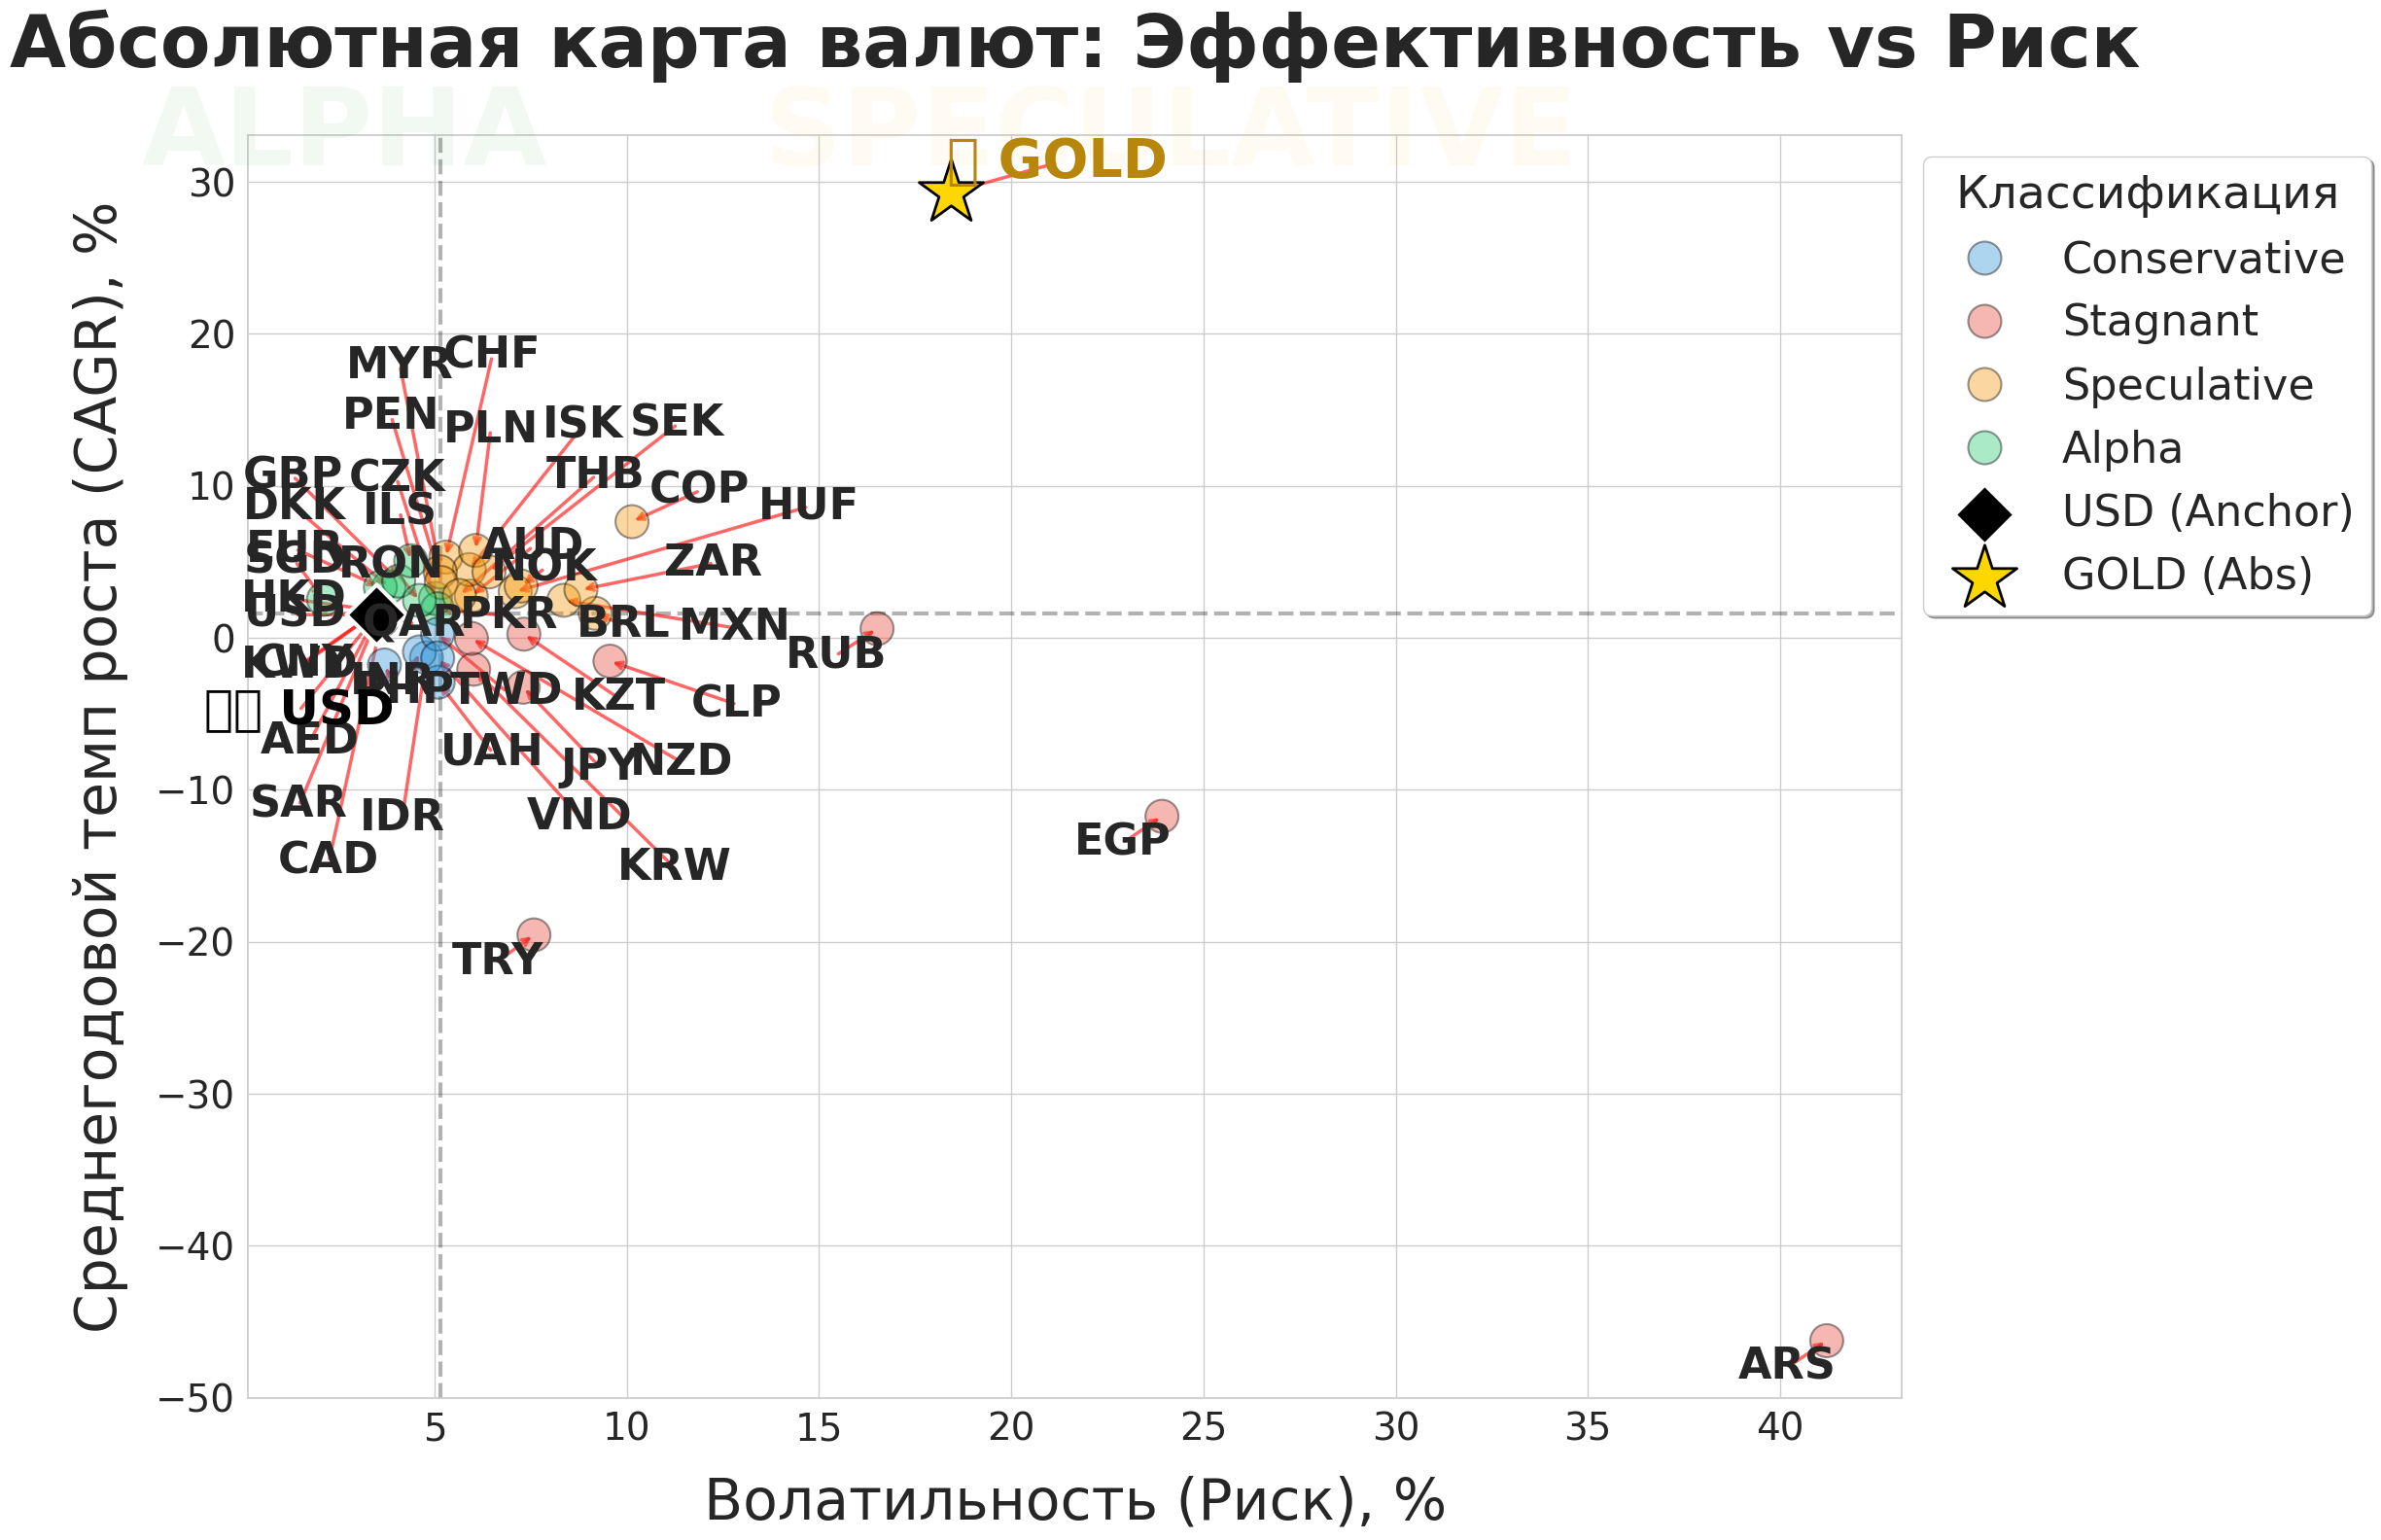

In [13]:
# =================================================================
# 6. CORE VISUALIZATION: ГИГАНТСКАЯ КАРТА ВАЛЮТНОЙ ЭФФЕКТИВНОСТИ
# =================================================================

from adjustText import adjust_text

# 1. Подготовка данных в процентах для осей
plot_metrics = df_metrics.copy()
plot_metrics['Return_pct'] = plot_metrics['Return'] * 100
plot_metrics['Risk_pct'] = plot_metrics['Risk'] * 100

plot_benchmarks = df_benchmarks.copy()
plot_benchmarks['Return_pct'] = plot_benchmarks['Return'] * 100
plot_benchmarks['Risk_pct'] = plot_benchmarks['Risk'] * 100

# 2. Создание ГИГАНТСКОЙ фигуры для маневра текста
plt.figure(figsize=(24, 16), dpi=100)
sns.set_style("whitegrid")

# Яркая палитра для стратегий
palette = {
    'Alpha': '#2ecc71',         # Зеленый
    'Speculative': '#f39c12',   # Оранжевый
    'Conservative': '#3498db',  # Синий
    'Stagnant': '#e74c3c'       # Красный
}

# 3. Отрисовка точек валют (крупные и полупрозрачные)
scatter = sns.scatterplot(
    data=plot_metrics, 
    x='Risk_pct', y='Return_pct', 
    hue='Quadrant', palette=palette,
    s=600, alpha=0.4, edgecolor='black', linewidth=1.5, zorder=5
)

# 4. Отрисовка "Якорей" (экстремально крупные символы)
plt.scatter(
    plot_benchmarks.loc['USD (Abs)', 'Risk_pct'], 
    plot_benchmarks.loc['USD (Abs)', 'Return_pct'], 
    marker='D', color='black', s=1000, label='USD (Anchor)', zorder=15, edgecolor='white', linewidth=3
)
plt.scatter(
    plot_benchmarks.loc['GOLD (Abs)', 'Risk_pct'], 
    plot_benchmarks.loc['GOLD (Abs)', 'Return_pct'], 
    marker='*', color='gold', s=2500, label='GOLD (Abs)', zorder=15, edgecolor='black', linewidth=2
)

# 5. Добавление ГИГАНТСКИХ подписей (Размер 32)
texts = []
for i in range(plot_metrics.shape[0]):
    texts.append(plt.text(
        plot_metrics['Risk_pct'].iloc[i], 
        plot_metrics['Return_pct'].iloc[i], 
        plot_metrics.index[i], 
        fontsize=32, 
        fontweight='black', 
        ha='center', va='center',
        zorder=20
    ))

# Специальные подписи для якорей
texts.append(plt.text(plot_benchmarks.loc['USD (Abs)', 'Risk_pct'], plot_benchmarks.loc['USD (Abs)', 'Return_pct'], 
                      '🇺🇸 USD', fontsize=36, weight='black', color='black', zorder=21))
texts.append(plt.text(plot_benchmarks.loc['GOLD (Abs)', 'Risk_pct'], plot_benchmarks.loc['GOLD (Abs)', 'Return_pct'], 
                      '🏆 GOLD', fontsize=40, weight='black', color='#b8860b', zorder=21))

# 6. Интенсивное раздвигание с четкими указателями
print("⏳ Оптимизируем расположение 45 подписей...")
adjust_text(
    texts, 
    expand_points=(2.5, 2.5), 
    expand_text=(2.2, 2.2),
    force_text=0.8,
    arrowprops=dict(arrowstyle='->', color='red', lw=2.5, alpha=0.6), # Жирные красные стрелки
    zorder=25
)

# 7. Финальное оформление и линии медиан
plt.title('Абсолютная карта валют: Эффективность vs Риск', fontsize=54, pad=50, fontweight='bold')
plt.xlabel('Волатильность (Риск), %', fontsize=42, labelpad=20)
plt.ylabel('Среднегодовой темп роста (CAGR), %', fontsize=42, labelpad=20)

# Осевые линии по медианам (жирные)
plt.axhline(median_return * 100, color='black', linestyle='--', linewidth=3, alpha=0.3, zorder=1)
plt.axvline(median_risk * 100, color='black', linestyle='--', linewidth=3, alpha=0.3, zorder=1)

# Укрупнение легенды и меток осей
plt.legend(title='Классификация', loc='upper left', bbox_to_anchor=(1, 1), 
           fontsize=32, title_fontsize=34, frameon=True, shadow=True)

plt.xticks(fontsize=28)
plt.yticks(fontsize=28)

# Названия квадрантов на фоне
ax = plt.gca()
xlim, ylim = ax.get_xlim(), ax.get_ylim()
plt.text(xlim[0]+(median_risk*100-xlim[0])/2, ylim[1]-2, 'ALPHA', fontsize=80, color='green', alpha=0.05, weight='black', ha='center')
plt.text(xlim[1]-(xlim[1]-median_risk*100)/2, ylim[1]-2, 'SPECULATIVE', fontsize=80, color='orange', alpha=0.05, weight='black', ha='center')

plt.tight_layout()
plt.savefig('currency_map_ultra_res.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# =================================================================
# 7. ТЕКСТОВЫЙ РЕЕСТР: КЛАССИФИКАЦИЯ ВАЛЮТ ПО КВАДРАНТАМ
# =================================================================
from IPython.display import Markdown, display

def get_quadrant_report(df):
    report = "## 📑 Итоговый реестр валют по категориям\n\n"
    report += "Ниже представлены все проанализированные активы, сгруппированные по их рыночному профилю.\n\n"
    
    # Сортируем внутри квадрантов по доходности для удобства
    quadrants = ['Alpha', 'Speculative', 'Conservative', 'Stagnant']
    titles = {
        'Alpha': "🏆 ALPHA (Лидеры эффективности)",
        'Speculative': "🚀 SPECULATIVE (Агрессивный рост)",
        'Conservative': "🛡️ CONSERVATIVE (Стабильные гавани)",
        'Stagnant': "⚠️ STAGNANT (Зона застоя)"
    }
    
    for quad in quadrants:
        subset = df[df['Quadrant'] == quad].sort_values('Return', ascending=False)
        if not subset.empty:
            report += f"### {titles[quad]}\n"
            items = []
            for ticker, row in subset.iterrows():
                # Формируем ссылку и форматируем проценты
                url = f"https://www.abscur.ru/p/2.html?abs={ticker}"
                ret_pct = row['Return'] * 100
                risk_pct = row['Risk'] * 100
                
                # Создаем Markdown ссылку с таргетом (в Markdown таргет зависит от рендерера, 
                # но стандартный синтаксис ссылок — лучший выбор для совместимости)
                link = f"[{ticker}]({url})"
                items.append(f"* {link} — Доходность: **{ret_pct:.2f}%**, Риск: **{risk_pct:.2f}%**")
            
            report += "\n".join(items) + "\n\n"
            
    return report

# Генерируем и отображаем отчет
markdown_report = get_quadrant_report(df_metrics)
display(Markdown(markdown_report))

## 📑 Итоговый реестр валют по категориям

Ниже представлены все проанализированные активы, сгруппированные по их рыночному профилю.

### 🏆 ALPHA (Лидеры эффективности)
* [ILS](https://www.abscur.ru/p/2.html?abs=ILS) — Доходность: **5.07%**, Риск: **4.38%**
* [GBP](https://www.abscur.ru/p/2.html?abs=GBP) — Доходность: **3.74%**, Риск: **4.06%**
* [DKK](https://www.abscur.ru/p/2.html?abs=DKK) — Доходность: **3.35%**, Риск: **3.81%**
* [EUR](https://www.abscur.ru/p/2.html?abs=EUR) — Доходность: **3.34%**, Риск: **3.59%**
* [CZK](https://www.abscur.ru/p/2.html?abs=CZK) — Доходность: **2.59%**, Риск: **5.02%**
* [SGD](https://www.abscur.ru/p/2.html?abs=SGD) — Доходность: **2.53%**, Риск: **2.11%**
* [RON](https://www.abscur.ru/p/2.html?abs=RON) — Доходность: **2.46%**, Риск: **4.61%**
* [PKR](https://www.abscur.ru/p/2.html?abs=PKR) — Доходность: **1.91%**, Риск: **5.08%**
* [HKD](https://www.abscur.ru/p/2.html?abs=HKD) — Доходность: **1.76%**, Риск: **3.56%**

### 🚀 SPECULATIVE (Агрессивный рост)
* [COP](https://www.abscur.ru/p/2.html?abs=COP) — Доходность: **7.64%**, Риск: **10.13%**
* [PLN](https://www.abscur.ru/p/2.html?abs=PLN) — Доходность: **5.75%**, Риск: **6.06%**
* [CHF](https://www.abscur.ru/p/2.html?abs=CHF) — Доходность: **5.31%**, Риск: **5.29%**
* [ISK](https://www.abscur.ru/p/2.html?abs=ISK) — Доходность: **4.49%**, Риск: **5.90%**
* [MYR](https://www.abscur.ru/p/2.html?abs=MYR) — Доходность: **4.34%**, Риск: **5.14%**
* [SEK](https://www.abscur.ru/p/2.html?abs=SEK) — Доходность: **4.34%**, Риск: **6.41%**
* [PEN](https://www.abscur.ru/p/2.html?abs=PEN) — Доходность: **3.64%**, Риск: **5.17%**
* [NOK](https://www.abscur.ru/p/2.html?abs=NOK) — Доходность: **3.41%**, Риск: **7.25%**
* [ZAR](https://www.abscur.ru/p/2.html?abs=ZAR) — Доходность: **3.17%**, Риск: **8.80%**
* [HUF](https://www.abscur.ru/p/2.html?abs=HUF) — Доходность: **3.04%**, Риск: **7.09%**
* [THB](https://www.abscur.ru/p/2.html?abs=THB) — Доходность: **2.79%**, Риск: **5.64%**
* [AUD](https://www.abscur.ru/p/2.html?abs=AUD) — Доходность: **2.75%**, Риск: **5.95%**
* [MXN](https://www.abscur.ru/p/2.html?abs=MXN) — Доходность: **2.47%**, Риск: **8.36%**
* [BRL](https://www.abscur.ru/p/2.html?abs=BRL) — Доходность: **1.62%**, Риск: **9.18%**

### 🛡️ CONSERVATIVE (Стабильные гавани)
* [SAR](https://www.abscur.ru/p/2.html?abs=SAR) — Доходность: **1.53%**, Риск: **3.54%**
* [USD](https://www.abscur.ru/p/2.html?abs=USD) — Доходность: **1.52%**, Риск: **3.49%**
* [AED](https://www.abscur.ru/p/2.html?abs=AED) — Доходность: **1.52%**, Риск: **3.50%**
* [KWD](https://www.abscur.ru/p/2.html?abs=KWD) — Доходность: **1.49%**, Риск: **3.36%**
* [QAR](https://www.abscur.ru/p/2.html?abs=QAR) — Доходность: **1.48%**, Риск: **3.70%**
* [CNY](https://www.abscur.ru/p/2.html?abs=CNY) — Доходность: **1.40%**, Риск: **3.32%**
* [CAD](https://www.abscur.ru/p/2.html?abs=CAD) — Доходность: **1.15%**, Риск: **3.62%**
* [TWD](https://www.abscur.ru/p/2.html?abs=TWD) — Доходность: **0.24%**, Риск: **5.08%**
* [PHP](https://www.abscur.ru/p/2.html?abs=PHP) — Доходность: **-0.92%**, Риск: **4.60%**
* [IDR](https://www.abscur.ru/p/2.html?abs=IDR) — Доходность: **-1.31%**, Риск: **4.79%**
* [VND](https://www.abscur.ru/p/2.html?abs=VND) — Доходность: **-1.32%**, Риск: **5.08%**
* [INR](https://www.abscur.ru/p/2.html?abs=INR) — Доходность: **-1.79%**, Риск: **3.69%**
* [UAH](https://www.abscur.ru/p/2.html?abs=UAH) — Доходность: **-2.92%**, Риск: **5.09%**

### ⚠️ STAGNANT (Зона застоя)
* [RUB](https://www.abscur.ru/p/2.html?abs=RUB) — Доходность: **0.60%**, Риск: **16.51%**
* [KZT](https://www.abscur.ru/p/2.html?abs=KZT) — Доходность: **0.24%**, Риск: **7.32%**
* [NZD](https://www.abscur.ru/p/2.html?abs=NZD) — Доходность: **-0.04%**, Риск: **5.96%**
* [CLP](https://www.abscur.ru/p/2.html?abs=CLP) — Доходность: **-1.53%**, Риск: **9.56%**
* [KRW](https://www.abscur.ru/p/2.html?abs=KRW) — Доходность: **-2.06%**, Риск: **6.01%**
* [JPY](https://www.abscur.ru/p/2.html?abs=JPY) — Доходность: **-3.25%**, Риск: **7.30%**
* [EGP](https://www.abscur.ru/p/2.html?abs=EGP) — Доходность: **-11.74%**, Риск: **23.92%**
* [TRY](https://www.abscur.ru/p/2.html?abs=TRY) — Доходность: **-19.55%**, Риск: **7.58%**
* [ARS](https://www.abscur.ru/p/2.html?abs=ARS) — Доходность: **-46.25%**, Риск: **41.21%**



### 📉 Аналитический отчет: Матрица валютной эффективности (2023–2026)

Результаты классификации 45 мировых валют в абсолютных координатах выявили четкую иерархию активов. Используя медианные значения рынка (Доходность: **1.62%**, Риск: **5.14%**), мы разделили глобальную корзину на четыре функциональные зоны.

#### 1. Зона ALPHA: Абсолютные лидеры
В эту группу вошли всего **9 активов** (20% рынка). Это «элита», сумевшая показать рост выше среднего при стабильности выше средней.
* **Бенефициары Европы:** GBP, EUR, DKK, CZK и RON синхронно укрепились, подтвердив устойчивость европейского региона в текущем цикле.
* **Технологичные гавани:** **SGD** (Сингапурский доллар) показал уникально низкий риск (**2.11%**), оставаясь одним из самых безопасных активов в мире.
* **Сюрприз цикла:** **ILS** (Израильский шекель) возглавил группу по доходности (**5.07%**), успешно адаптировавшись к внешним шокам.

#### 2. SPECULATIVE: Энергия роста через риск
Самая крупная группа (**14 активов**). Здесь находятся валюты, которые «зарабатывают», но требуют крепких нервов.
* **Сырьевой драйвер:** **COP** (Колумбийское песо) показало самый высокий CAGR (**7.64%**), но и риск здесь двузначный.
* **Пограничные состояния:** **CHF** (Швейцарский франк) и **PLN** (Польский злотый) находятся на самой границе с зоной Alpha. Малейшее снижение волатильности переведет их в разряд идеальных активов.

#### 3. CONSERVATIVE: Территория «Якорей»
Группа из **13 активов**, работающих в режиме сбережения.
* **Долларовая зона:** **USD** и привязанные к нему валюты Залива (SAR, AED, KWD, QAR) движутся единым фронтом. Их доходность (1.4–1.5%) чуть ниже медианы, что делает их эталоном сохранения, но не приумножения.
* **Азиатский дрейф:** CNY, INR и IDR показывают отрицательную или околонулевую динамику, оставаясь при этом низковолатильными.

#### 4. STAGNANT: Зона разрушения стоимости
Группа из **9 активов**, которые математически неэффективны для удержания «в долгую».
* **Эпицентры девальвации:** ARS, TRY и EGP демонстрируют катастрофический отрыв — их риск (до 41%) несопоставим с глубоко отрицательной доходностью.
* **Валютные ловушки:** **RUB** (0.60% доходности при риске 16.51%) и **JPY** (-3.25% доходности) наглядно показывают, что высокая волатильность не всегда вознаграждается прибылью.

---

### 💡 Резюме для инвестора
Карта подтверждает: **Золото (CAGR 29.3%)** в этом цикле полностью затмило фиатные деньги как инструмент роста. Однако внутри валютного мира группа **Alpha** (особенно SGD, EUR, GBP) остается фундаментом для тех, кто ищет баланс между предсказуемостью доллара и доходностью развивающихся рынков.